# Import Dataset From Kaggle

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shantanudhakadd/bank-customer-churn-prediction")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/shantanudhakadd/bank-customer-churn-prediction


# Importing Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Update the filename if it differs in the downloaded dataset folder
file_path = '/kaggle/input/datasets/shantanudhakadd/bank-customer-churn-prediction/Churn_Modelling.csv' 
df = pd.read_csv(file_path)

# Display the first few rows to understand the data structure
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Data Preprocessing

In [3]:
# Drop irrelevant columns
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Encode categorical variables
label_encoder = LabelEncoder()

# Assuming 'Geography' and 'Gender' are categorical columns in your dataset
if 'Geography' in df.columns:
    df['Geography'] = label_encoder.fit_transform(df['Geography'])
if 'Gender' in df.columns:
    df['Gender'] = label_encoder.fit_transform(df['Gender'])

# Define features (X) and target variable (y)
# Assuming 'Exited' or 'Churn' is the target column
target_col = 'Exited' if 'Exited' in df.columns else 'Churn'
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-Test Split

In [4]:
# Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (8000, 10)
Testing features shape: (2000, 10)


# Initialize and Train the Gradient Boosting Model

In [6]:
# Initialize the Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,      # Number of boosting stages to perform
    learning_rate=0.1,     # Shrinks the contribution of each tree
    max_depth=3,           # Maximum depth of the individual regression estimators
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

# Model Evaluation

In [8]:
# Make predictions
y_pred = gb_model.predict(X_test)

# Evaluate the model
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

Model Accuracy: 0.866

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000


Confusion Matrix:
 [[1547   60]
 [ 208  185]]


# Feature Importance (Optional but Recommended)

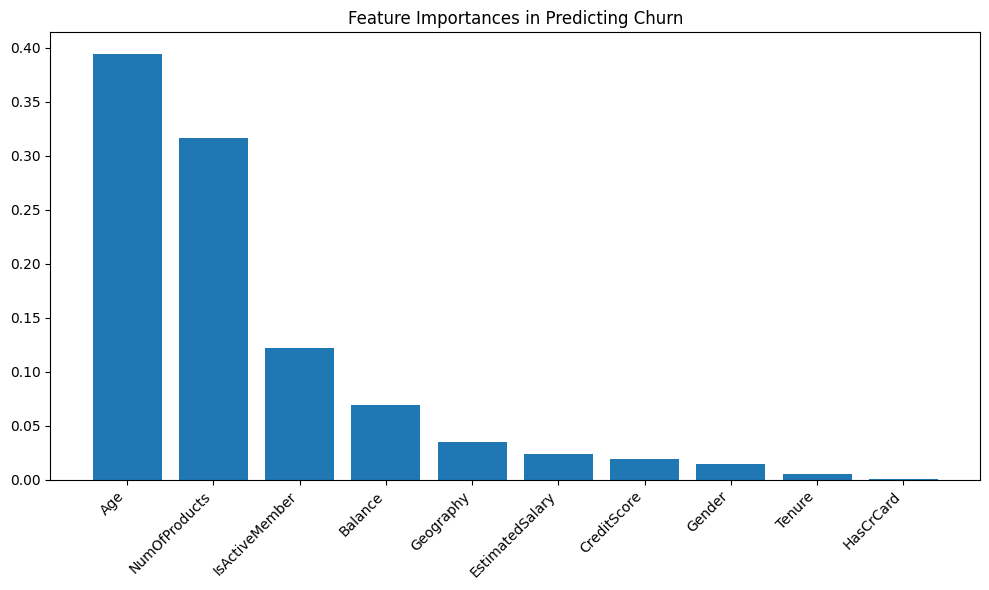

In [9]:
# Plot feature importances
feature_importances = gb_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances in Predicting Churn")
plt.bar(range(X.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visual Confusion Matrix (Heatmap)

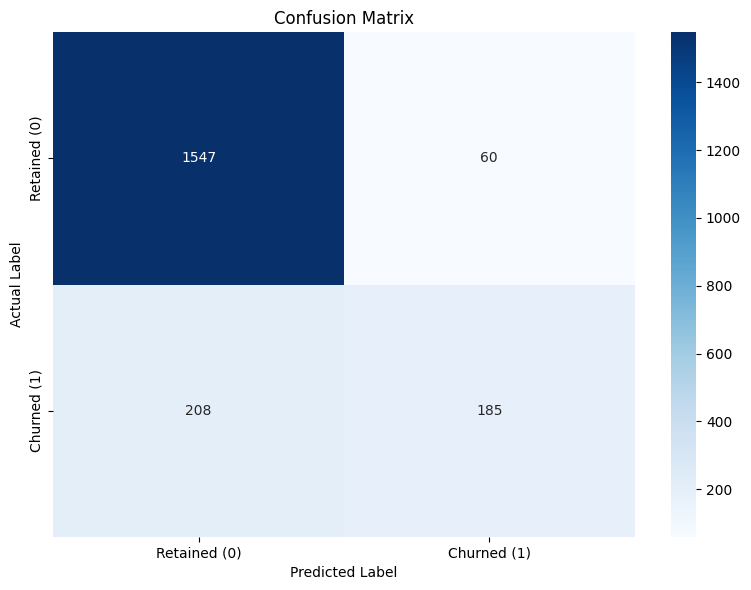

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming 'conf_matrix' is already calculated from your previous cell
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Receiver Operating Characteristic (ROC) Curve

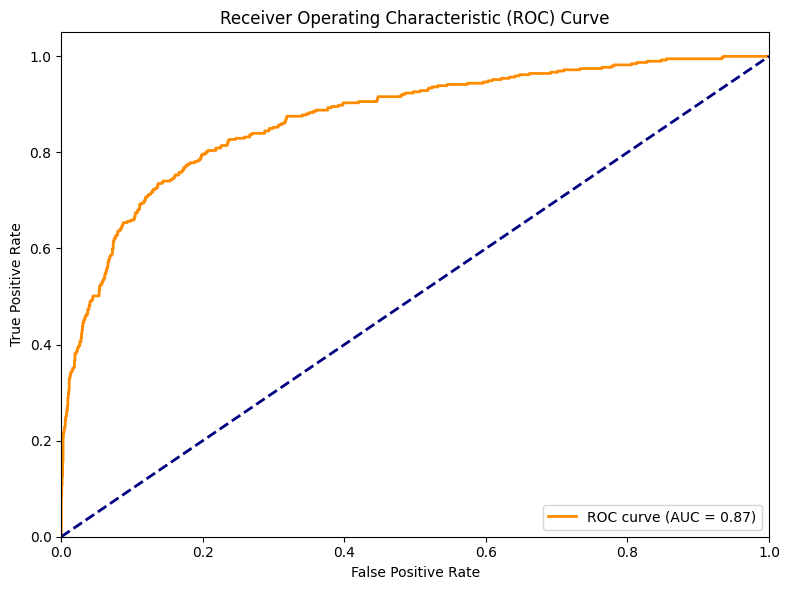

In [11]:
from sklearn.metrics import roc_curve, auc

# Get prediction probabilities for the positive class (Churned)
y_prob = gb_model.predict_proba(X_test)[:, 1]

# Calculate ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Precision-Recall Curve

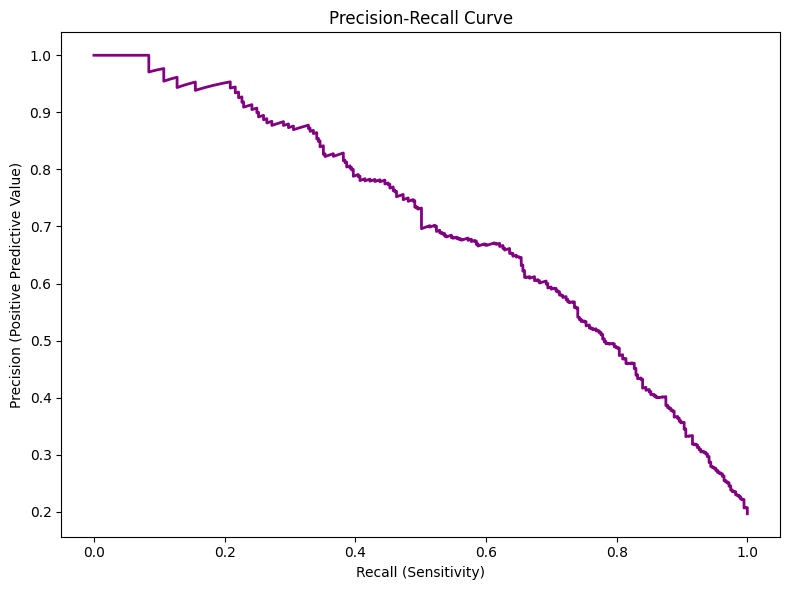

In [12]:
from sklearn.metrics import precision_recall_curve

# Calculate Precision-Recall metrics
precision, recall, _ = precision_recall_curve(y_test, y_prob)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

# Eporting the model

In [17]:
import joblib

# Define the file path in your Kaggle working directory
model_filename = '/kaggle/working/gb_churn_model.joblib'

# Export the trained model
joblib.dump(gb_model, model_filename)

print(f"Model successfully exported to: {model_filename}")

Model successfully exported to: /kaggle/working/gb_churn_model.joblib


# Exporting the Label Encoder

In [18]:
# Save the label encoder as well
encoder_filename = '/kaggle/working/label_encoder.joblib'
joblib.dump(label_encoder, encoder_filename)

print(f"Label encoder successfully exported to: {encoder_filename}")

Label encoder successfully exported to: /kaggle/working/label_encoder.joblib
